# Telco Customer Churn Analysis

## Step 1: Data Loading and Cleaning

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('Set2')

In [4]:
# Load the dataset
df = pd.read_csv('Telco-Customer-Churn.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Check data types and missing values
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Handle missing values in TotalCharges
print(f"Missing TotalCharges: {df['TotalCharges'].isnull().sum()}")
df = df.dropna(subset=['TotalCharges'])
print(f"Dataset shape after dropping missing values: {df.shape}")

Missing TotalCharges: 11
Dataset shape after dropping missing values: (7032, 21)


## Step 2: Exploratory Data Analysis (EDA)

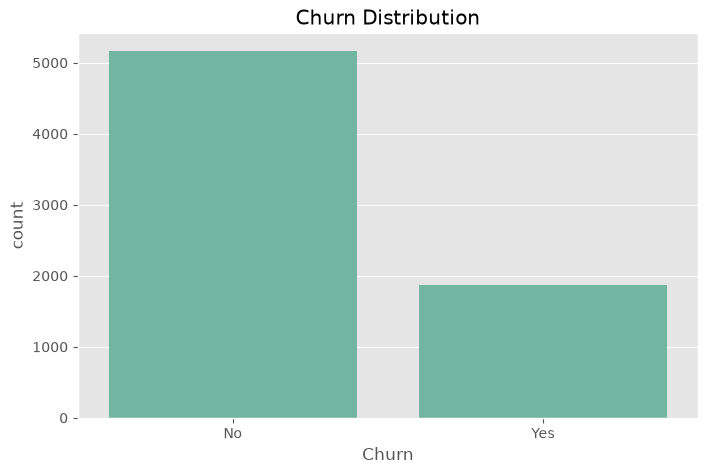

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


In [7]:
# Churn distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

print(df['Churn'].value_counts(normalize=True))

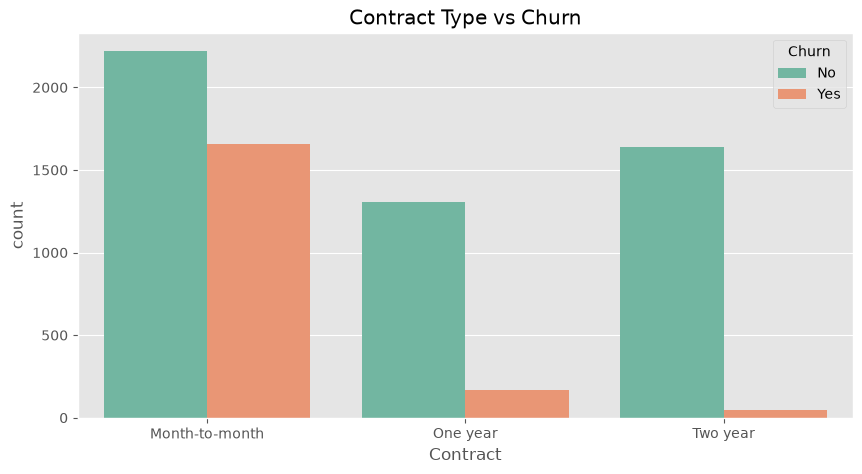

In [8]:
# Contract type vs churn
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.show()

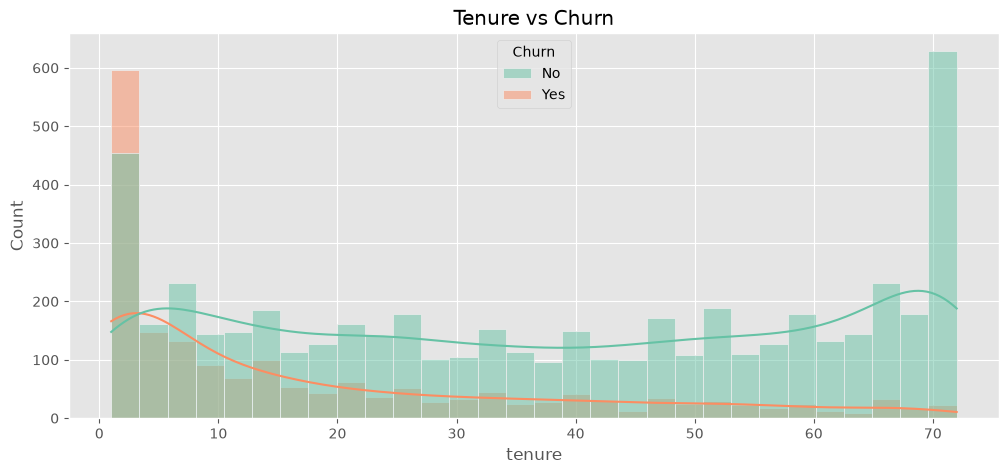

In [9]:
# Tenure vs churn
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, bins=30)
plt.title('Tenure vs Churn')
plt.show()

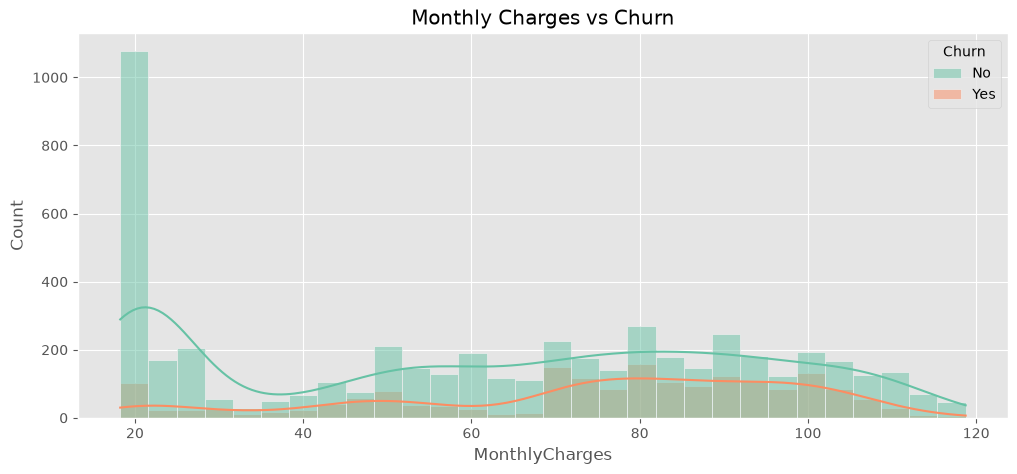

In [10]:
# Monthly charges vs churn
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, bins=30)
plt.title('Monthly Charges vs Churn')
plt.show()

## Step 3: Feature Engineering

In [11]:
# Drop customerID
df = df.drop('customerID', axis=1)

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Label encode target variable
le = LabelEncoder()
y = le.fit_transform(y)

# One-hot encode categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (7032, 30)
Target shape: (7032,)


In [12]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

## Step 4: Model Training and Evaluation

In [13]:
def evaluate_model(y_true, y_pred, y_pred_proba):
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_pred_proba))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [14]:
# Logistic Regression
print("=== Logistic Regression ===")
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred_lr, y_pred_proba_lr)

=== Logistic Regression ===
Accuracy: 0.8045486851457001
Precision: 0.6504559270516718
Recall: 0.5721925133689839
F1-score: 0.6088193456614509
ROC-AUC: 0.8360714082341553

Confusion Matrix:
[[918 115]
 [160 214]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [15]:
# Random Forest
print("\n=== Random Forest ===")
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred_rf, y_pred_proba_rf)


=== Random Forest ===
Accuracy: 0.7882018479033405
Precision: 0.6233766233766234
Recall: 0.5133689839572193
F1-score: 0.5630498533724341
ROC-AUC: 0.8156283810716929

Confusion Matrix:
[[917 116]
 [182 192]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [16]:
# XGBoost (if available)
try:
    from xgboost import XGBClassifier
    print("\n=== XGBoost ===")
    xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]
    evaluate_model(y_test, y_pred_xgb, y_pred_proba_xgb)
except ImportError:
    print("\nXGBoost not available, skipping.")


=== XGBoost ===
Accuracy: 0.7782515991471215
Precision: 0.5890804597701149
Recall: 0.5481283422459893
F1-score: 0.5678670360110804
ROC-AUC: 0.8196701368217795

Confusion Matrix:
[[890 143]
 [169 205]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407

